**U-net network for image segmentation** 

In [1]:
#!pip install imagecodecs
#!pip install --upgrade tifffile imagecodecs

In [1]:
import tensorflow as tf
import glob
import os
import numpy as np

2026-04-27 18:06:51.610357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777313211.889117      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777313211.964153      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777313212.588387      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777313212.588434      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777313212.588437      55 computation_placer.cc:177] computation placer alr

**Encoder**

In [2]:
def encoder_block(inputs, num_filters):

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    p = tf.keras.layers.MaxPool2D((2,2))(x)

    return x, p  

**Decoder**

In [3]:
def decoder_block(inputs, skip_features, num_filters):

    x = tf.keras.layers.Conv2DTranspose(
        num_filters, (2, 2), strides=2, padding='same'
    )(inputs)

    x = tf.keras.layers.Concatenate()([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

**Defining the Unet model**

In [4]:
def unet_model(input_shape=(512, 512, 3), num_classes=1):

    inputs = tf.keras.layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    #s4, p4 = encoder_block(p3, 512)

    # bottleneck
    b1 = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(p3)
    b1 = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(b1)

    #d1 = decoder_block(b1, s4, 512)
    d1 = decoder_block(b1, s3, 256)
    d2 = decoder_block(d1, s2, 128)
    d3 = decoder_block(d2, s1, 64)

    outputs = tf.keras.layers.Conv2D(num_classes, 1, activation='sigmoid')(d3)

    return tf.keras.Model(inputs, outputs)

if __name__ == '__main__':
    model = unet_model(input_shape=(512, 512, 3), num_classes=1)
    model.summary()

2026-04-27 18:07:27.712404: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ conv2d_3[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 128, 128,  │          0 │ conv2d_4[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    590,080 │ activation_4[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_2[

 Total params: 7,697,345 (29.36 MB)

 Trainable params: 7,697,345 (29.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
def unet_model2(input_shape=(512, 512, 3), num_classes=1):

    inputs = tf.keras.layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same', activation='relu')(p4)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same', activation='relu')(b1)

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = tf.keras.layers.Conv2D(num_classes, 1, activation='sigmoid')(d4)

    return tf.keras.Model(inputs, outputs)

if __name__ == '__main__':
    model = unet_model2(input_shape=(512, 512, 3), num_classes=1)
    model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 512, 512,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 512, 512,  │          0 │ conv2d_15[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 512, 512,  │     36,928 │ activation_12[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 512, 512,  │          0 │ conv2d_16[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 256, 256,  │          0 │ activation_13[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 256, 256,  │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 256, 256,  │          0 │ conv2d_17[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 256, 256,  │    147,584 │ activation_14[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 256, 256,  │          0 │ conv2d_18[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ activation_15[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │    295,168 │ max_pooling2d_4[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 128, 128,  │          0 │ conv2d_19[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │    590,080 │ activation_16[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 128, 128,  │          0 │ conv2d_20[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ activation_17[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_5[

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

**data loading**

**Load paths**

In [11]:
import os
import glob

ROOT = "/kaggle/input/datasets/cedricniango"

IMAGE_DIR = os.path.join(ROOT, "dir-01-png")
MASK_DIR  = os.path.join(ROOT, "01-gt-seg-png")


def get_dataset_paths(image_dir, mask_dir):

    image_paths = sorted(glob.glob(os.path.join(image_dir, "t*.png")))

    mask_files = set(os.listdir(mask_dir))

    image_list = []
    mask_list = []

    for img_path in image_paths:

        name = os.path.basename(img_path)
        idx = ''.join(filter(str.isdigit, name))

        mask_name = f"man_seg{idx}.png"

        if mask_name in mask_files:
            image_list.append(img_path)
            mask_list.append(os.path.join(mask_dir, mask_name))

    print(f"Matched pairs: {len(image_list)}")

    return image_list, mask_list

**Image Preprocessing and mask** 

In [12]:
import imageio.v2 as imageio
#import tifffile as tiff
import tensorflow as tf
import numpy as np

IMG_SIZE = 512

def load_sample(img_path, mask_path):

    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels=1)

    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask, channels=1)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))

    img = tf.cast(img, tf.float32) / 255.0
    mask = tf.cast(mask > 0, tf.float32)

    return img, mask

**Data augmentation**

In [13]:
'''def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    return img, mask'''

def augment(img, mask):

    # horizontal flip 
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # vertical flip 
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # 90° Rotation 
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    mask = tf.image.rot90(mask, k)

    # Brightness (image only)
    img = tf.image.random_brightness(img, max_delta=0.1)

    # Contrast (image only)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)

    # 
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.02)
    img = img + noise

    # Clipping
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, mask

**RANDOM CROP**

In [14]:
def random_crop(img, mask, crop_size=256):
    #Concate image and mask for identically crop
    combined = tf.concat([img, mask], axis=-1)

    cropped = tf.image.random_crop(
        combined,
        size=[crop_size, crop_size, combined.shape[-1]]
    )

    img_crop = cropped[..., :img.shape[-1]]
    mask_crop = cropped[..., img.shape[-1]:]

    return img_crop, mask_crop

**Dataset creation**

In [15]:
def create_dataset(image_paths, mask_paths, batch_size=8, augment_data=True):

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    
    dataset = dataset.map(
        load_sample,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    #Cropping
    dataset = dataset.map(
        lambda x, y : random_crop(x, y, 256),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if augment_data:
        dataset = dataset.map(
            augment,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.shuffle(100)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

**Usage**

In [16]:
ROOT = "DIC-C2DH-HeLa"
IMAGE_DIR = "/kaggle/input/datasets/cedricniango/dir-01-png"
MASK_DIR = "/kaggle/input/datasets/cedricniango/01-gt-seg-png"

IMAGE_DIR_valid = "/kaggle/input/datasets/cedricniango/dir-02-png"
MASK_DIR_valid = "/kaggle/input/datasets/cedricniango/02-gt-seg-png"

train_img, train_mask = get_dataset_paths(IMAGE_DIR, MASK_DIR)
valid_img, valid_mask = get_dataset_paths(IMAGE_DIR_valid, MASK_DIR_valid)

train_dataset = create_dataset(train_img, train_mask, batch_size=4, augment_data=True)
valid_dataset  = create_dataset(valid_img, valid_mask, batch_size=4, augment_data=False)

Matched pairs: 9
Matched pairs: 9


**VERIFICATION**

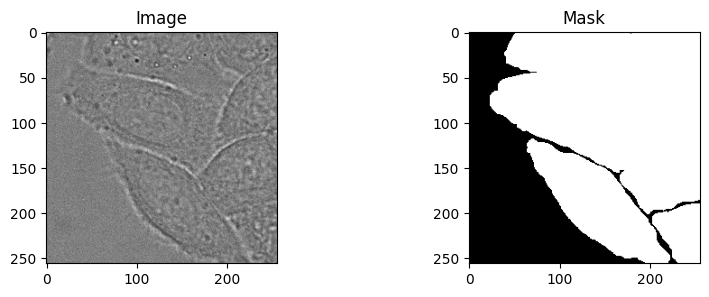

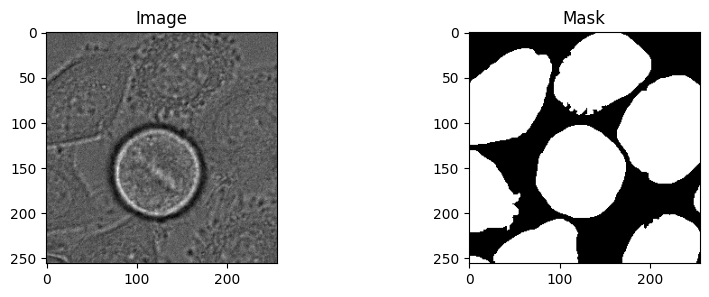

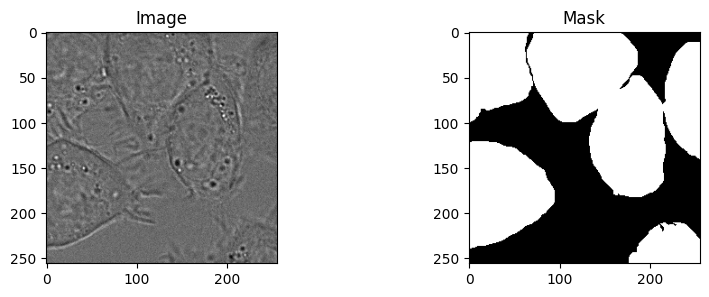

In [17]:
import matplotlib.pyplot as plt

def show_sample(ds):
    for img, mask in ds.take(4):
        plt.figure(figsize=(10,3))

        plt.subplot(1,2,1)
        plt.title("Image")
        plt.imshow(img[0,...,0], cmap='gray')

        plt.subplot(1,2,2)
        plt.title("Mask")
        plt.imshow(mask[0,...,0], cmap='gray')

        plt.show()

show_sample(train_dataset)

**Weight map**: $w(x) = w_{c}(x) + w_{0}·exp−\frac{
(d_{1}(x) + d_{2}(x))^2}{2σ^2}$

In [61]:
from collections import defaultdict
import cv2 

#Weight map
#Sources: https://github.com/Miltos-90/UNet_Biomedical_Image_Segmentation/blob/main/utils.py

def _class_weights(mask):
    ''' Create a dictionary containing the classes in a mask,
        and their corresponding weights to balance their occurence
    '''
    
    wc = defaultdict()

    # Grab classes and their corresponding counts
    unique, counts = np.unique(mask, return_counts = True)

    # Convert counts to frequencies
    counts = counts / np.prod(mask.shape)

    # Get max. counts
    max_count = np.max(counts)

    for val, count in zip(unique, counts):
        wc[val] = max_count / (count + 1e-8)
    
    return wc

def weight_map(mask, w0, sigma, background_class = 0):

    #Convert tensorflow tensor -> numpy
    if isinstance(mask, tf.Tensor):
        mask = mask.numpy()
    
    # Fix mask datatype (should be unsigned 8 bit)
    if mask.dtype != 'uint8': 
        mask = mask.astype('uint8')
    
    # Weight values to balance classs frequencies
    wc = _class_weights(mask)
    
    # Assign a different label to each connected region of the image
    _, regions = cv2.connectedComponents(mask)
    
    # Get total no. of connected regions in the image and sort them excluding background
    region_ids = sorted(np.unique(regions))
    region_ids = [region_id for region_id in region_ids if region_id != background_class]
        
    if len(region_ids) > 1: # More than one connected regions

        # Initialise distance matrix (dimensions: H x W x no.regions)
        distances = np.zeros((mask.shape[0], mask.shape[1], len(region_ids)))

        # For each region
        for i, region_id in enumerate(region_ids):

            # Mask all pixels belonging to a different region
            m = (regions != region_id).astype(np.uint8)# * 255
        
            # Compute Euclidean distance for all pixels belongind to a different region
            distances[:, :, i] = cv2.distanceTransform(m, distanceType = cv2.DIST_L2, maskSize = 0)

        # Sort distances w.r.t region for every pixel
        distances = np.sort(distances, axis = 2)

        # Grab distance to the border of nearest region
        d1, d2 = distances[:, :, 0], distances[:, :, 1]

        # Compute RHS of weight map and mask background pixels
        w = w0 * np.exp(-1 / (2 * sigma ** 2)  * (d1 + d2) ** 2) * (regions == background_class)

    else: # Only a single region present in the image
        w = np.zeros_like(mask)

    # Instantiate a matrix to hold class weights
    wc_x = np.zeros_like(mask)
    
    # Compute class weights for each pixel class (background, etc.)
    for pixel_class, weight in wc.items():
    
        wc_x[mask == pixel_class] = weight
    
    # Add them to the weight map
    w = w + wc_x
    
    return w

UNIQUE values: [0. 1.]
UNIQUE values: [0. 1.]
UNIQUE values: [0. 1.]
UNIQUE values: [0. 1.]


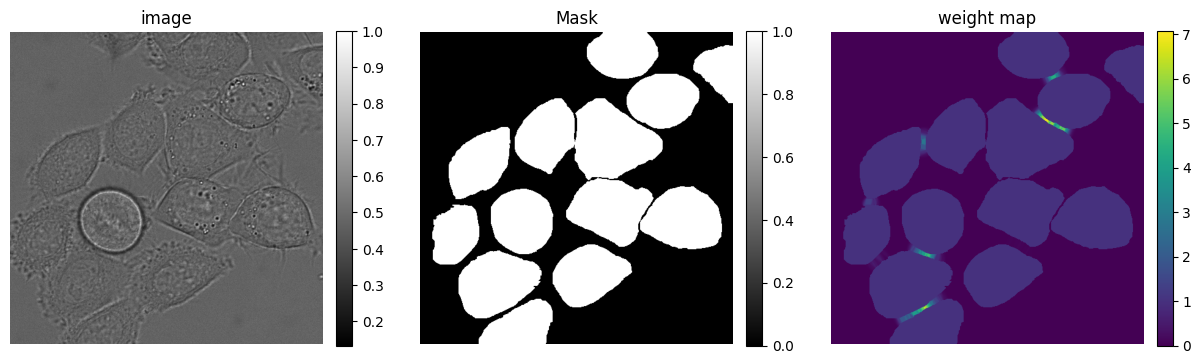

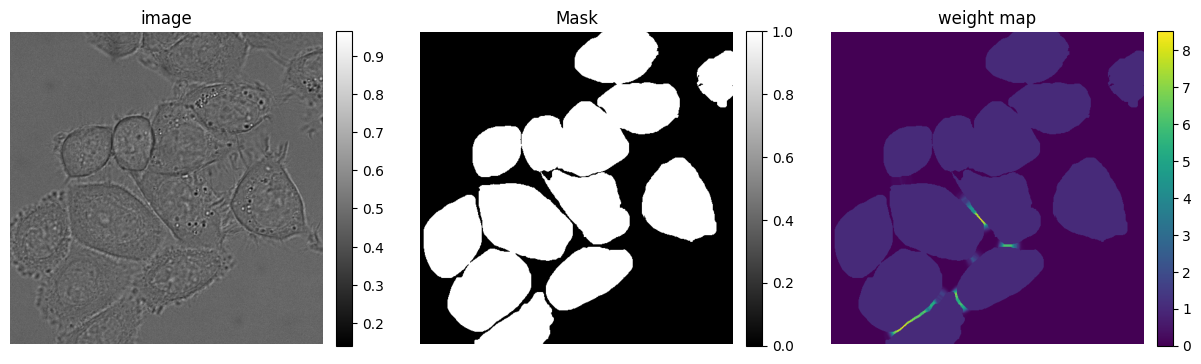

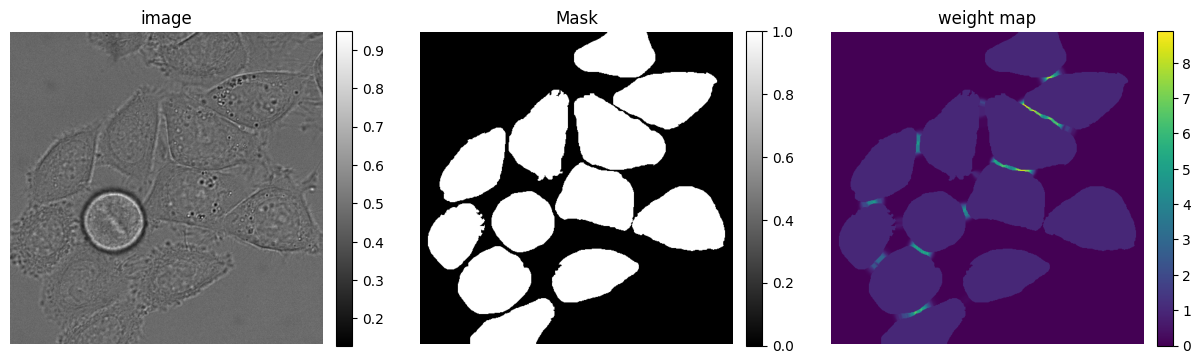

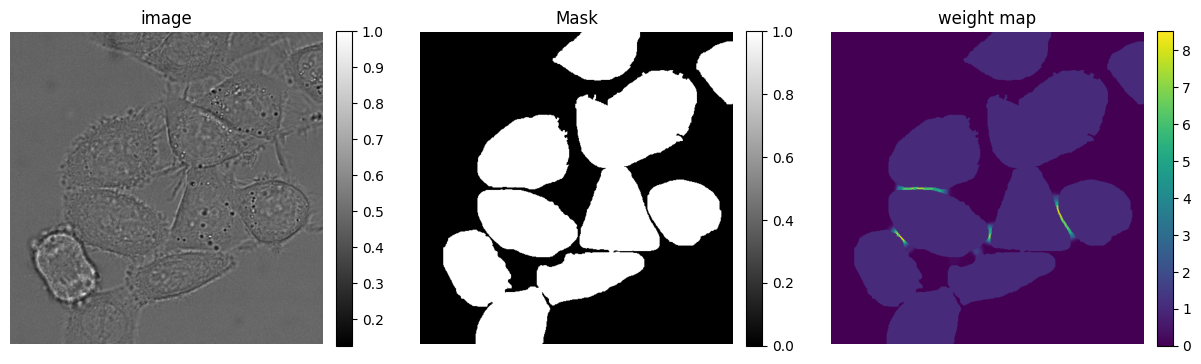

In [63]:
#Sources: https://github.com/Miltos-90/UNet_Biomedical_Image_Segmentation/blob/main/Unet_main.ipynb
# Parameters used by the authors
w0    = 10
sigma = 5
#print(f"SHAPE: {train_mask[0]}")
#sample_img, sample_mask = load_sample(train_img[0], train_mask[0]) 
#print(f"SHAPE sample img: {sample_img.shape} SHAPE MASK: {sample_mask.shape}")
for i in np.random.randint(0, len(train_img), 4): # Randomly draw 3 images

    img, mask = load_sample(train_img[i], train_mask[i])
    #img = img.numpy().astype(np.uint8)
    #mask = mask.numpy().astype(np.uint8)
    # Grab image and label map
    #print(f"TRAIN mask: {}")
    mask = mask[:, :, 0]
    img  = img[:, :, 0]

    print(f"UNIQUE values: {np.unique(mask)}")

    #print(f"DTYPE MASK: {mask.dtype} and DTYPE IMG: {img.dtype}")

    # Compute weight map
    w = weight_map(mask = mask, w0 = w0, sigma = sigma)
    
    # Plot results
    fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (15, 15));

    im = ax[0].imshow(img, 'gray')
    plt.colorbar(im, ax = ax[0], fraction = 0.046, pad = 0.04)
    ax[0].axis('off')
    ax[0].set_title('image')

    im = ax[1].imshow(mask, 'gray')
    plt.colorbar(im, ax = ax[1], fraction = 0.046, pad = 0.04)
    ax[1].axis('off')
    ax[1].set_title('Mask')

    im = ax[2].imshow(w)
    plt.colorbar(im, ax = ax[2], fraction = 0.046, pad = 0.04)
    ax[2].axis('off');
    ax[2].set_title('weight map');

**TRAINING AND LOSS FUNCTION**

*Loss function*

In [31]:
# Loss BCE (Binary cross-entropy): https://softwaremill.com/instance-segmentation-loss-functions/
# Loss Dice : https://www.tensorflow.org/api_docs/python/tf/keras/losses/Dice
def dice_loss(y_true, y_pred, epsi=1e-7):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    #epsi = 1e-7
    #dice loss = 1 - dice_score
    return 1 - (2 * tf.reduce_sum(y_true * y_pred)) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + epsi) #Intersection / Union


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * d_loss

**Compile model**

In [32]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [33]:
IMAGE_SIZE = 256
model = unet_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1), num_classes=1)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
             loss=bce_dice_loss,
             metrics=["accuracy"]
             )

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=50,              # nb of epochs without improvement
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    #verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor="val_loss",
    mode='min',
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=1000,
    callbacks=[reduce_lr]
    #callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.4224 - loss: 0.5822 - val_accuracy: 0.6939 - val_loss: 0.5531 - learning_rate: 1.0000e-04
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.5702 - loss: 0.5784 - val_accuracy: 0.6853 - val_loss: 0.5503 - learning_rate: 1.0000e-04
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.6119 - loss: 0.5656 - val_accuracy: 0.7354 - val_loss: 0.5317 - learning_rate: 1.0000e-04
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - accuracy: 0.5837 - loss: 0.5668 - val_accuracy: 0.7400 - val_loss: 0.5190 - learning_rate: 1.0000e-04
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.5900 - loss: 0.5587 - val_accuracy: 0.6258 - val_loss: 0.5395 - learning_rate: 1.0000e-04
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.6145 - loss: 0.5445 - val_accuracy: 0.6688 - val_loss: 0.5093 - learning_rate: 1.0000e-04
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - accuracy: 0.

In [25]:
# Save model
model.save("unet_model_1K_rlr_256x256.keras")

**Plot training curves**

In [26]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]

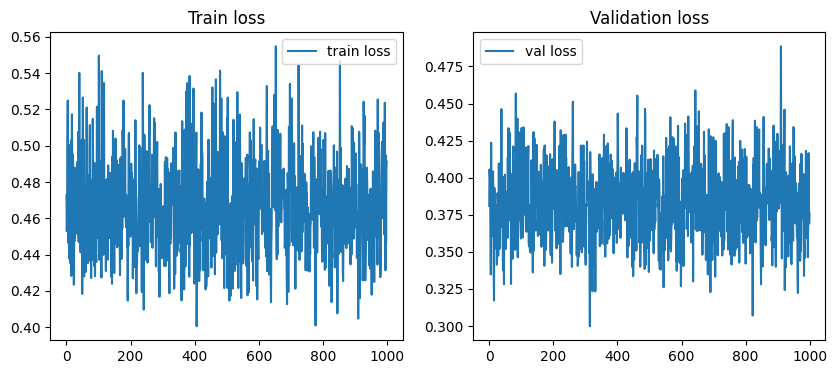

In [27]:
import matplotlib.pyplot as plt

def plot_training(history):

    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train loss")
    plt.title("Train loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title("Validation loss")
    plt.legend()

    # Accuracy (si disponible)
    '''if "accuracy" in history.history:
        plt.subplot(1,2,2)
        plt.plot(history.history["accuracy"], label="train acc")
        plt.plot(history.history["val_accuracy"], label="val acc")
        plt.title("Accuracy")
        plt.legend()'''

    plt.show()

plot_training(history)

**Save curves**

In [28]:
import json

with open("history.json", "w") as f:
    json.dump(history.history, f)

**INFERENCE**

In [29]:
def load_test_image(path):

    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)

    img = tf.image.resize(img, (512, 512))
    img = tf.cast(img, tf.float32) / 255.0

    return img

def create_test_dataset(image_paths, batch_size=4):

    dataset = tf.data.Dataset.from_tensor_slices(image_paths)

    dataset = dataset.map(
        lambda x: load_test_image(x),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


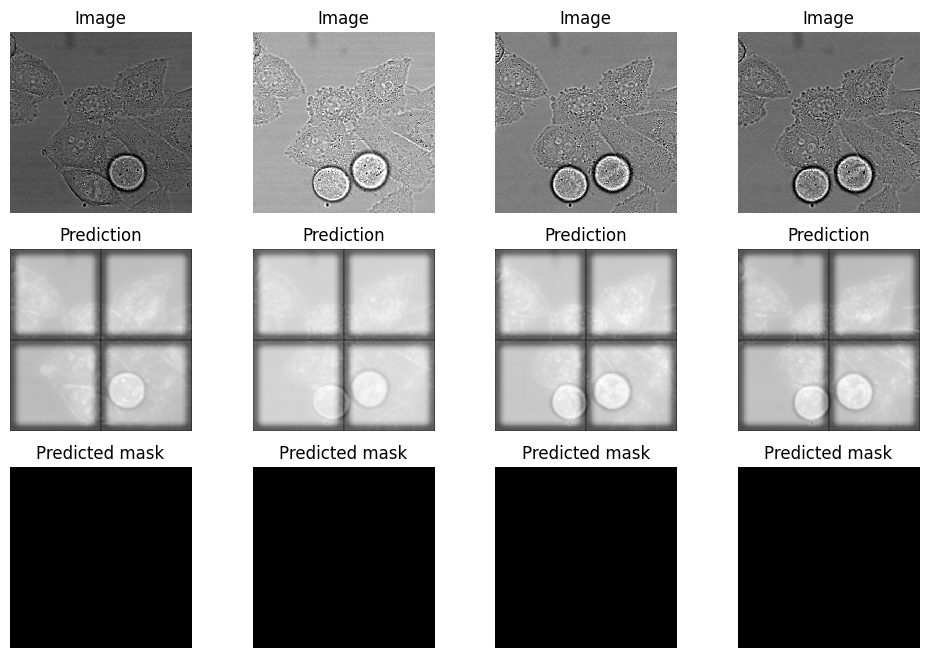

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


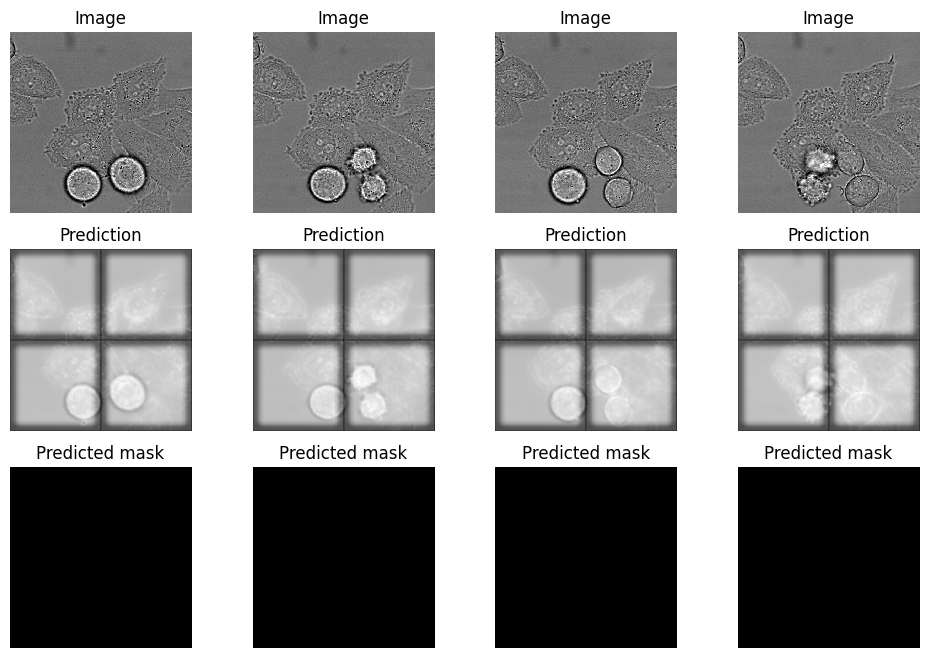

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


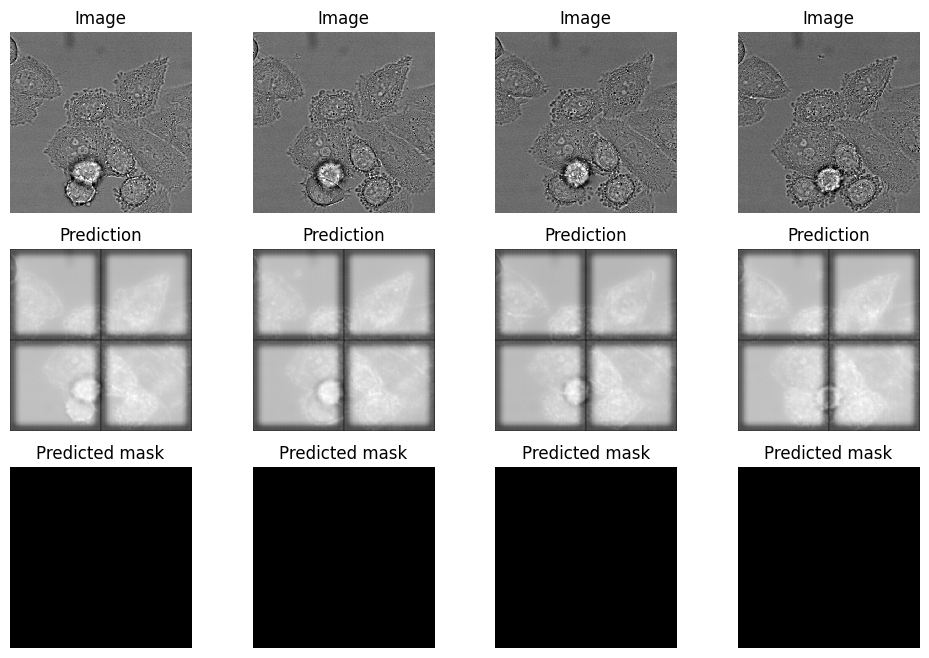

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


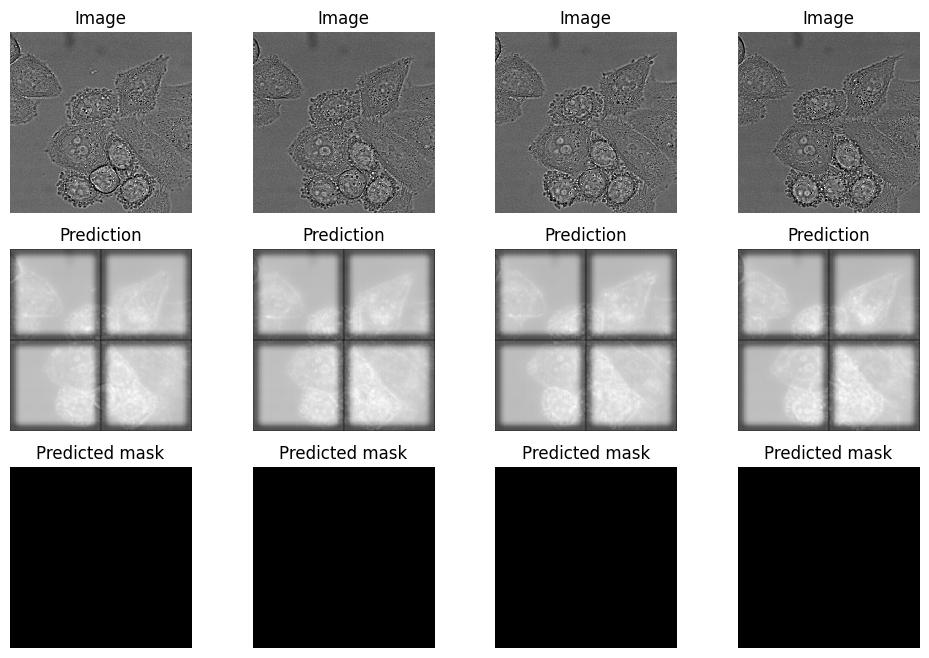

In [30]:
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import glob

#Load model
model = tf.keras.models.load_model(
                                  '/kaggle/working/unet_model_1K_rlr_256x256.keras',
                                   compile=False)

# Test set
IMAGE_DIR_test = "/kaggle/input/datasets/cedricniango/dir-01-test-png"
test_img = sorted(glob.glob(os.path.join(IMAGE_DIR_test, '*.png')))
test_dataset = create_test_dataset(test_img, batch_size=4)

'''def show_predictions(model, dataset):

    for img, mask in dataset.take(1):

        pred = model.predict(img)

        plt.figure(figsize=(12,4))

        # Image
        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img[0,...,0], cmap="gray")

        # Ground truth
        plt.subplot(1,3,2)
        plt.title("Mask GT")
        plt.imshow(mask[0,...,0], cmap="gray")

        # Prediction
        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred[0,...,0] > 0.5, cmap="gray")

        plt.show()

show_predictions(model, test_dataset)'''
#preds = model.predict(test_dataset)
import numpy as np

def predict_with_overlap(model, imgs, patch_size=256, stride=128):

    batch_size, H, W, C = imgs.shape

    final_pred = np.zeros((batch_size, H, W, 1), dtype=np.float32)
    counter = np.zeros((batch_size, H, W, 1), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch = imgs[:, y:y+patch_size, x:x+patch_size, :]
            final_pred[:, y:y+patch_size, x:x+patch_size, :] += model.predict(patch)
            counter[:, y:y+patch_size, x:x+patch_size, :] += 1

    final_pred /= counter

    return final_pred

def predict_with_split(model, imgs, IMG_SIZE = 256):
    ##predict on patches
    #print(f"SHAPE: {imgs.shape}") Input: 4 x 512 x 512 x 1
    preds11 = model.predict(imgs[:, :IMG_SIZE, :IMG_SIZE, :])
    preds12 = model.predict(imgs[:, :IMG_SIZE, IMG_SIZE:, :])
    preds21 = model.predict(imgs[:, IMG_SIZE:, :IMG_SIZE, :])
    preds22 = model.predict(imgs[:, IMG_SIZE:, IMG_SIZE:, :])
    #Concat differente tensors
    preds1 = tf.concat([preds11, preds12], axis=2)
    #print(f"preds1: {preds1.shape}")
    preds2 = tf.concat([preds21, preds22], axis=2)
    #print(f"preds2: {preds2.shape}")
    #Final image
    preds = tf.concat([preds1, preds2], axis=1)
    return preds

IMG_SIZE = 256
def show_predictions(dataset, model):

    for imgs in dataset.take(4):
        '''
        ##predict on patches
        #print(f"SHAPE: {imgs.shape}") Input: 4 x 512 x 512 x 1
        preds11 = model.predict(imgs[:, :IMG_SIZE, :IMG_SIZE, :])
        preds12 = model.predict(imgs[:, :IMG_SIZE, IMG_SIZE:, :])
        preds21 = model.predict(imgs[:, IMG_SIZE:, :IMG_SIZE, :])
        preds22 = model.predict(imgs[:, IMG_SIZE:, IMG_SIZE:, :])
        #Concat differente tensors
        preds1 = tf.concat([preds11, preds12], axis=2)
        #print(f"preds1: {preds1.shape}")
        preds2 = tf.concat([preds21, preds22], axis=2)
        #print(f"preds2: {preds2.shape}")
        #Final image
        preds = tf.concat([preds1, preds2], axis=1)'''
        #preds = predict_with_overlap(model, imgs)
        preds = predict_with_split(model, imgs)

        plt.figure(figsize=(12,8))

        for i in range(4):

            plt.subplot(3,4,i+1)
            plt.imshow(imgs[i], cmap='gray', interpolation='nearest')
            plt.title("Image")
            plt.axis("off")

            plt.subplot(3,4,i+5)
            plt.imshow(preds[i,...,0], cmap="gray", interpolation='nearest')
            #print(f"MAX values of preds: {preds[i,...,0].max()}")
            #print(f"MIN values of preds: {preds[i,...,0].min()}")
            plt.title("Prediction")
            plt.axis("off")

            plt.subplot(3,4,i+9)
            plt.imshow(preds[i,...,0] > 0., cmap="gray", interpolation='nearest')
            #print(f"MAX values of preds: {preds[i,...,0].max()}")
            #print(f"MIN values of preds: {preds[i,...,0].min()}")
            plt.title("Predicted mask")
            plt.axis("off")

        plt.show()
show_predictions(test_dataset, model)